# Post-merge analysis & interpretation — Sox2 cohesin simulations

Iterative analysis notebook for the polymer simulations of `chr3:34–36 Mb` (mm10) under mESC vs neuron cohesin parameters. Consumes pooled and per-replicate contact maps written to `../results/analysis/` by `scripts/run_analysis_all.py`, runs the same scientific analyses (contact maps + CTCF overlay, P(s) + power-law fit, AbLE on conserved anchors, two-point MSD, polymer dynamics) **interactively**, and ends with cross-condition comparisons.

**When to use this notebook.** After a fresh batch of merged simulations + a `submit_analysis_postmerge.sh` run produces JSON / PNG outputs, but you want to:

- Replot with different colour scales, vmin/vmax, panel layouts.
- Tweak P(s) fit windows or AbLE hyperparameters and see the effect.
- Hand-pick MSD probe pairs, change lag windows, refit α / K_α.
- Compare conditions side-by-side without going back to SLURM.
- Sanity-check intermediate values before committing analysis-code changes.

The cluster job is still the canonical pipeline; this notebook is for *interactive iteration on top of it*.

**What this notebook does NOT do.** It does not run polychrom 3D simulations, does not run `merge_shards.py`, does not retouch the cluster-side analysis caches. It only reads `*_contact_map.npy`, `*_ps.json`, MSD `*.npz`, polymer-dynamics `*.json`, and BED files.



## Theory primer — what the analyses are measuring and why

The four core readouts (contact map → P(s), AbLE loop strength, two-point MSD, polymer dynamics) probe complementary aspects of the same loop-extrusion physics. Read this once before tuning anything; the interpretation cells below assume this framing.

**Notation in this notebook (consistent with `analysis/msd_two_point.py`, `compare_ctcf_swap.ipynb`, and the Hansen-lab `chromatin_dynamics` package).**

| symbol | quantity | definition |
|---|---|---|
| **β** | P(s) decay exponent | `P(s) ~ s^(-β)` |
| **ν** | spatial-separation exponent | `R(s) ~ s^ν`, with `β = 3ν` by mean field |
| **α** | MSD sub-diffusion exponent | `MSD(τ) = K_α · τ^α` |
| **K_α** | MSD prefactor | `K_α = MSD(τ=1 saved-frame unit)` |

> ⚠️ Symbol-mismatch warning. Grosse-Holz, Mirny & Coulon 2025 (PNAS Nexus, see below) use **μ** for the MSD sub-diffusion exponent — what we and Mazzocca/Hansen 2025 call **α**. They are the same quantity. We use **α** throughout this notebook to stay consistent with the code (`fit_msd_alpha` in `analysis/msd_two_point.py`) and the most recent dynamics paper.

**Loop-extrusion model (Fudenberg et al. 2016 *Cell Reports* 15:2038; Sanborn et al. 2015 *PNAS* 112:E6456; Banigan et al. 2020 *eLife* 9:e53558).** Cohesin loads stochastically on chromatin, extrudes a progressively larger loop with two motor heads, and unloads after a finite processivity (~150 kb in mESC per Gabriele 2022). CTCF acts as a directional barrier: a forward-oriented (`>`) site stops the head moving rightward; a reverse (`<`) site stops the head moving leftward. Convergent CTCF pairs (`> ... <`) are therefore the canonical loop anchors visible as dots in Hi-C / Micro-C maps.

**Contact probability P(s).** The probability that two monomers separated by genomic distance `s` are in physical contact, decaying approximately as a power law `P(s) ~ s^(-β)` over a chosen distance window. **β is an empirical scaling exponent, not a clean polymer-state label** — the same chromatin can show different β at short, mid, and long range simultaneously. Reference values from the polymer-physics + Hi-C literature:

- **β ≈ 1.5** — equilibrium globule / Rouse random walk (Lieberman-Aiden et al. 2009 baseline; rare in vivo, observed in yeast).
- **β ≈ 1.0** — fractal / crumpled globule (Grosberg, Nechaev & Shakhnovich 1988 *J. Phys.*; Mirny 2011 review). The canonical short-range value; Lieberman-Aiden 2009 measured β ≈ 1.08 in human Hi-C.
- **β ≈ 1.0–1.3** — typical metazoan in vivo, 10 kb–1 Mb (Bonev et al. 2017 — this project's reference data).
- **shallower β at intermediate scales** — strong loop extrusion. Gassler et al. 2017 (Wapl-KO "vermicelli"): β as low as ~0.7–0.9 at extruded scales. Regime-specific scaling, not a textbook polymer-state name.

By mean field `β = 3ν` (Grosse-Holz, Mirny & Coulon 2025): the metazoan space-filling structure (`R(s) ~ s^(1/3)`, ν = 1/3) gives exactly the observed β ≈ 1.

Mirny-style piecewise fits (Gassler 2017; Polovnikov et al. 2023) separate the short-range non-scaling regime (s < ~2 kb) from the scaling regime (~2–30 kb at our 1 kb resolution) where β is read off the linear log-log slope.

**AbLE — Absolute Loop Estimator (Jusuf et al. 2025 bioRxiv 2025.01.13.632736, PMC11812599).** A per-loop scalar that quantifies how much *more* contact a CTCF–CTCF anchor pair makes than the genome-wide P(s) baseline predicts. For each loop:

1. Take a square sub-image of the contact map around the anchors.
2. Fit `image ≈ c · P(s)` by least-squares against the genome-wide P(s) curve, masking the diagonal and outlier loops.
3. Score = sum, inside a circular disk centred on the anchor pair, of `(image − c·P(s))`.

Higher AbLE = stronger anchor-anchor preference over what extrusion alone would give. AbLE is approximately additive across replicates and roughly proportional to the fraction of cells with that loop instantaneously closed.

**Two-point MSD.** The mean-squared displacement of the *vector* between two monomers as a function of lag time τ:

\[ \mathrm{MSD}_{2pt}(\tau) = \langle |\vec r(t+\tau) - \vec r(t)|^2 \rangle_t, \qquad \vec r = \vec p_b - \vec p_a \]

The pair's centre-of-mass drift cancels by construction, so this is a clean readout of *internal* polymer dynamics. We fit `MSD(τ) = K_α · τ^α`. Reference values:

- **α ≈ 1.0** — free diffusion (textbook).
- **α ≈ 0.5** — classical Rouse polymer (theoretical baseline).
- **α ≈ 0.4 = 2/5** — fractal-globule prediction (Tamm et al. 2015).
- **α ≈ 0.3** — *current best in vivo estimate*, robust across 7 orders of magnitude in time, from MINFLUX + classical SPT in mouse and human cells. **Mazzocca, Narducci, Grosse-Holz, Matthias & Hansen 2025 bioRxiv 2025.05.10.653248.** This supersedes earlier α ≈ 0.5–0.6 SPT estimates (Gabriele 2022, Mach 2022), which were artefacts of insufficient time resolution and motion blur.
- **α ≈ 0.1–0.25 (plateau)** — loop-trapped pair, MSD saturates at 2J (J = loop end-to-end variance).

> ⚠️ Loop-extrusion direction (counterintuitive). Mazzocca 2025 finds that acute cohesin loss *raises* α — i.e. loop extrusion is *constraining*. Predicted direction in our sweeps: high-cohesin / long-residence neuron parameters → **lower α** than mESC control, opposite to a naive "more diffusion in compact globule" reasoning. The size of the gap reports the strength of cohesin-mediated constraint.

**Polymer dynamics extras.** Radius-of-gyration time-courses (`Rg(t)`), looped-fraction time-series, contact dwell-time distributions, and pair-distance distributions probe population-level state of the polymer rather than tagged-pair dynamics. Bimodal `P(|r|)` (peak at small `|r|` = looped, broader peak at large `|r|` = unlooped) is the signature of a stable loop population.

### The unified scale-free framework — Grosse-Holz, Mirny & Coulon 2025

A useful way to read the rest of this notebook is through the lens of **Grosse-Holz, Mirny & Coulon 2025** *"Scale-free models of chromosome structure, dynamics, and mechanics"*, **PNAS Nexus 4(12):pgaf337**, doi:10.1093/pnasnexus/pgaf337 (PMC12706471). They argue that the three classes of observables we look at downstream — P(s) from contact maps, MSD from two-point tracking, and (separately) the force response of a single locus — are not independent: a self-consistent scale-free description of chromatin requires their scaling exponents to satisfy two algebraic relations, and **no single classical polymer model (Rouse, Zimm, fractal globule) simultaneously matches all observed metazoan exponents**.

| symbol (this notebook) | observable | metazoan in vivo (current best) | toy-model values |
|---|---|---|---|
| **ν** | spatial separation: `R(s) ~ s^ν` | ≈ 0.33 (space-filling) | Rouse 1/2 · fractal globule 1/3 |
| **β = 3ν** | contact probability: `P(s) ~ s^(-β)` | ≈ 1.0 | Rouse 3/2 · fractal globule 1 |
| **α** (Grosse-Holz μ) | single-locus MSD: `MSD(τ) ~ τ^α` | **≈ 0.3** (Mazzocca 2025 MINFLUX) | Rouse 1/2 · fractal globule 2/5 · Zimm 2/3 |
| **α_solv** (Grosse-Holz α) | nucleoplasm viscoelasticity (free tracer MSD) | ≈ 0.5–1 (poorly constrained) | viscous fluid 1 |
| **δ** | finite-coil hydrodynamic radius scaling | unmeasured | freely draining 1 · Zimm ν |
| **ρ, ψ** | force-response exponents | ρ ≈ 0.5, ψ ≈ 1 (Mach 2024) | Rouse ρ = 1/2, ψ = 1 |

Two consistency relations from Grosse-Holz Eq. 7 (translated to our α-for-MSD notation):

1. **Structure ↔ dynamics.** Rouse predicts ν = α = 1/2 (matches yeast). Fractal globule predicts ν = 1/3 with α = 2/5. The metazoan combination ν ≈ 0.33 + α ≈ 0.3 violates *both* — the deviation has to be absorbed by either viscoelastic nucleoplasm (α_solv ≠ 1) or intermediate hydrodynamic correlations (ν < δ < 1).
2. **Dynamics ↔ mechanics.** ρ · ψ = α. With the experimentally measured ψ ≈ 1, ρ = α — so the force-response exponent equals the MSD sub-diffusion exponent. Mach 2024 verified this in cells.

What this means for our cross-condition comparisons: a single observable in isolation is ambiguous; the *triple* (β, α, looped fraction) on the same condition is where interpretation earns its keep. If neuron parameters shift β: 1.0 → 0.85 (more extruded) but α stays at 0.3, that combination points (per Grosse-Holz 2025) at a scale-dependent active process — exactly what loop extrusion is — rather than a simple polymer-state change.



In [37]:
# =============================================================================
# Cell 1 — TUNABLE GLOBALS (edit here, re-run-all)
# =============================================================================
# Path conventions follow CLAUDE.md "Disk paths" invariants. Outputs go to
# ../results/figures/ unless you point FIGURES_DIR somewhere else.

from __future__ import annotations
from pathlib import Path
import os, sys, json, glob, warnings, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

REPO_ROOT     = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ANALYSIS_DIR  = REPO_ROOT / "results" / "analysis"
SIMS_DIR      = REPO_ROOT / "results" / "polychrom_3d"
FIGURES_DIR   = REPO_ROOT / "results" / "figures"
DATA_DIR      = REPO_ROOT / "data"
MCOOL_MESC    = DATA_DIR / "mcool" / "ES_chr3.mcool"
MCOOL_NEURON  = DATA_DIR / "mcool" / "CN_chr3.mcool"

# Make project modules importable
for sub in ("", "analysis", "scripts", "configs"):
    p = REPO_ROOT / sub if sub else REPO_ROOT
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from configs import parameters as P
RESOLUTION   = P.RESOLUTION         # 1000 bp / monomer
N_MONOMERS   = P.N_MONOMERS         # 2000
REGION_START = P.REGION_START       # 34_000_000
REGION_END   = P.REGION_END         # 36_000_000
CHROM        = P.CHROM              # "chr3"

# Plot style
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "axes.titlesize": 11,
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9,
})
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"REPO_ROOT     = {REPO_ROOT}")
print(f"ANALYSIS_DIR  = {ANALYSIS_DIR}  exists={ANALYSIS_DIR.exists()}")
print(f"SIMS_DIR      = {SIMS_DIR}      exists={SIMS_DIR.exists()}")
print(f"FIGURES_DIR   = {FIGURES_DIR}")
print(f"RESOLUTION    = {RESOLUTION} bp/bin   N_MONOMERS = {N_MONOMERS}")
print(f"Region        = {CHROM}:{REGION_START:,}-{REGION_END:,} (mm10)")


REPO_ROOT     = C:\Users\gabriele.michele\Documents\Claude\Projects\3D_genome_in_neurons\cohesin_sim
ANALYSIS_DIR  = C:\Users\gabriele.michele\Documents\Claude\Projects\3D_genome_in_neurons\cohesin_sim\results\analysis  exists=True
SIMS_DIR      = C:\Users\gabriele.michele\Documents\Claude\Projects\3D_genome_in_neurons\cohesin_sim\results\polychrom_3d      exists=False
FIGURES_DIR   = C:\Users\gabriele.michele\Documents\Claude\Projects\3D_genome_in_neurons\cohesin_sim\results\figures
RESOLUTION    = 1000 bp/bin   N_MONOMERS = 2000
Region        = chr3:34,000,000-36,000,000 (mm10)


## 1. Discover available conditions

`scripts/run_analysis_all.py` writes flat outputs into `results/analysis/` with the prefix scheme `{condition}_{n_blocks}blk_rep{rep}_*` for per-replicate outputs and `{condition}_{total_blocks}blk_pooled_*` for pooled-across-replicates outputs (see CLAUDE.md "Disk paths" / "Naming conventions"). The next cell parses every contact-map file in that folder and groups them by condition / replicate.

If the cell finds nothing, you probably haven't run the cluster job yet:

```
sbatch cluster/submit_merge_shards.sh           # only if needed
sbatch cluster/submit_analysis_postmerge.sh     # produces the files this notebook reads
```



In [38]:
# Discover contact-map files and parse condition / rep / pool.
CMAP_RE = re.compile(
    r"^(?P<cond>.+?)_(?P<nblocks>\d+)blk"
    r"(?:_rep(?P<rep>\d+)|_pooled)"
    r"_contact_map\.npy$"
)

records = []
for npy in sorted(ANALYSIS_DIR.glob("*_contact_map.npy")):
    m = CMAP_RE.match(npy.name)
    if not m:
        continue
    rep = int(m["rep"]) if m["rep"] is not None else None
    records.append({
        "condition": m["cond"], "n_blocks": int(m["nblocks"]),
        "rep": rep, "is_pooled": rep is None,
        "prefix": npy.name.replace("_contact_map.npy", ""),
        "path": npy,
    })

if not records:
    print("No *_contact_map.npy files found under", ANALYSIS_DIR)
    print("Run cluster/submit_analysis_postmerge.sh first, or check the path.")
else:
    conds = sorted({r["condition"] for r in records})
    print(f"{len(records)} contact-map files across {len(conds)} conditions:")
    for c in conds:
        sub = [r for r in records if r["condition"] == c]
        reps = sorted(r["rep"] for r in sub if not r["is_pooled"])
        pooled = any(r["is_pooled"] for r in sub)
        print(f"  {c:40s}  reps={reps}  pooled={'yes' if pooled else 'no'}")

# Build a quick-lookup: condition -> {"pooled": prefix, "reps": {rep: prefix}}
by_condition = {}
for r in records:
    bucket = by_condition.setdefault(r["condition"], {"pooled": None, "reps": {}})
    if r["is_pooled"]:
        bucket["pooled"] = r["prefix"]
    else:
        bucket["reps"][r["rep"]] = r["prefix"]

CONDITIONS = sorted(by_condition.keys())


6 contact-map files across 5 conditions:
  CN_baseline_ctcf-neuron                   reps=[]  pooled=yes
  CN_long_residency_ctcf-neuron             reps=[5]  pooled=yes
  CN_very_long_residency_ctcf-neuron        reps=[]  pooled=yes
  mESC_ctcf-mESC                            reps=[]  pooled=yes
  mESC_ctcf-neuron                          reps=[]  pooled=yes


## 2. Contact maps with CTCF arrow overlay

The simulated dense contact map for a region of size `N_MONOMERS × N_MONOMERS` is produced by the file-parallel Hansen-style extractor in `analysis/contact_maps.py` (one worker per `blocks_*.h5`, returns a partial `(N_locus, N_locus)` map; see CLAUDE.md "Memory landmines" for why this is the safe pattern). Each pixel `[i, j]` is the number of frames in which monomer `j` was within the contact-distance threshold of monomer `i`, summed across all replicates' shards (when pooled) or just one replicate (when per-rep).

Visualisation tips:

- `vmax` should be the 95th–99th percentile of off-diagonal values to avoid the diagonal saturating the colour scale.
- Convergent CTCF pairs (`> ... <`) are the canonical loop anchors — the dots that appear off-diagonal. Plot them as arrows below the heatmap to align orientation with apparent loop dots.
- For sim-vs-experiment side-by-side, the dual-triangle layout (sim above the diagonal, balanced experimental Hi-C below) is the cleanest visual.

The next cell renders one selected condition. Edit `cond` and `vmax_quantile` at the top of the cell to change the view.



Loaded CN_baseline_ctcf-neuron_235800blk_pooled_contact_map.npy   shape=(2000, 2000)   dtype=float64


C:\Users\gabriele.michele\AppData\Local\Temp\ipykernel_53744\1121089804.py:21: RuntimeWarning: divide by zero encountered in log10
  cm_plot = np.where(cm > 0, np.log10(cm), np.nan)


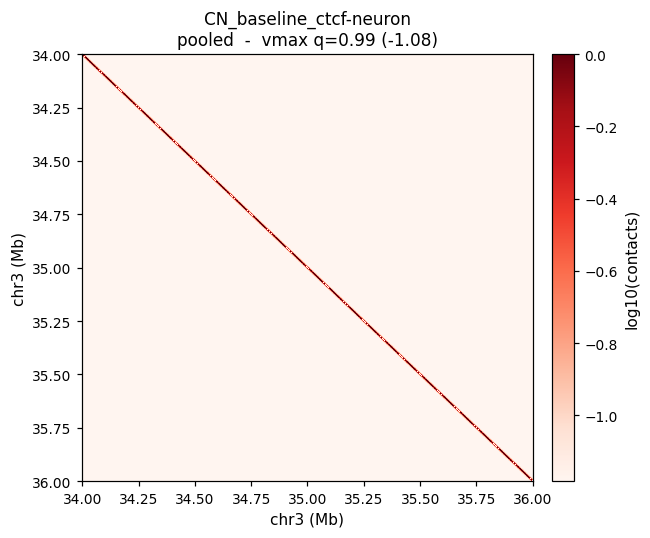

In [39]:
# Tunables for this cell
cond = CONDITIONS[0] if CONDITIONS else None
vmax_quantile = 0.99
which = "pooled"   # "pooled" or an int rep index

if cond is None:
    print("(no conditions discovered; skip)")
else:
    bucket = by_condition[cond]
    if which == "pooled" and bucket["pooled"]:
        prefix = bucket["pooled"]
    else:
        rep = which if isinstance(which, int) else min(bucket["reps"])
        prefix = bucket["reps"][rep]
    cmap_path = ANALYSIS_DIR / f"{prefix}_contact_map.npy"
    cm = np.load(cmap_path)
    print(f"Loaded {prefix}_contact_map.npy   shape={cm.shape}   dtype={cm.dtype}")

    fig, ax = plt.subplots(figsize=(6, 5))
    # Use log scale for dynamic range; mask zeros
    cm_plot = np.where(cm > 0, np.log10(cm), np.nan)
    vmax = np.nanquantile(cm_plot, vmax_quantile)
    extent_mb = [REGION_START / 1e6, REGION_END / 1e6,
                 REGION_END / 1e6, REGION_START / 1e6]
    im = ax.imshow(cm_plot, cmap="Reds", vmin=0, vmax=vmax, extent=extent_mb,
                   interpolation="nearest", aspect="auto")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="log10(contacts)")
    ax.set_xlabel(f"{CHROM} (Mb)")
    ax.set_ylabel(f"{CHROM} (Mb)")
    ax.set_title(f"{cond}\n{which}  -  vmax q={vmax_quantile:.2f} ({vmax:.2f})")
    fig.tight_layout()
    plt.show()

    # Try CTCF arrow overlay if a BED is present
    ctcf_bed = DATA_DIR / "ctcf_oriented_CONSERVED_mESC_CN_chr3.bed"
    if ctcf_bed.exists():
        sites = []
        with open(ctcf_bed) as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                if len(parts) < 6 or parts[0] != CHROM:
                    continue
                start, end, ori = int(parts[1]), int(parts[2]), parts[5]
                if start < REGION_START or end > REGION_END:
                    continue
                sites.append({"pos": (start + end) // 2, "ori": ori})
        if sites:
            fig2, ax2 = plt.subplots(figsize=(6, 1.0))
            for s in sites:
                x = s["pos"] / 1e6
                if s["ori"] == "+":
                    ax2.annotate("", xy=(x + 0.02, 0), xytext=(x, 0),
                                 arrowprops=dict(arrowstyle="->", color="C0", lw=1.5))
                else:
                    ax2.annotate("", xy=(x - 0.02, 0), xytext=(x, 0),
                                 arrowprops=dict(arrowstyle="->", color="C3", lw=1.5))
            ax2.set_xlim(extent_mb[0], extent_mb[1])
            ax2.set_ylim(-0.5, 0.5)
            ax2.set_yticks([])
            ax2.set_xlabel(f"{CHROM} (Mb)")
            ax2.set_title(f"Conserved CTCF orientation ({len(sites)} sites)")
            ax2.spines[["top", "right", "left"]].set_visible(False)
            fig2.tight_layout()
            plt.show()


## 3. P(s) curves and power-law fit

Compute P(s) by averaging each diagonal of the dense contact map (`analysis/ps_curve.compute_ps_curve`), overlay all conditions, and fit `P(s) ~ s^(-β)` in log-log space over the chosen scaling window (default 2–30 kb, Mirny / Gassler convention). β reports the empirical scaling regime — see the theory primer at the top for reference values and caveats.

> Symbol convention: **β** is the P(s) decay exponent here (`P(s) ~ s^(-β)`, with `β = 3ν` by mean field). The MSD section uses **α** for the sub-diffusion exponent (`MSD(τ) ~ τ^α`); they are different quantities, distinct symbols. Some literature (Grosse-Holz 2025) uses μ instead of α for MSD — translate when reading.

**Tunables:** the fit window (`lower_bound_bp`, `upper_bound_bp`) and which conditions to overlay. Tighten the window if the curve has obvious deviations from power-law at the boundaries.

**Interpretation cues:** a flatter curve (smaller β) at high cohesin density / longer residence — that's the direction we expect for the neuron parameters in this project. A steeper curve (larger β) at the chosen scale would suggest something like Wapl-rescue or weakened extrusion. The TAD-scale "shoulder" around the locus boundary should be inspected separately via the derivative `d log P / d log s`.



CN_baseline_ctcf-neuron              beta = 1.374
CN_long_residency_ctcf-neuron        beta = 1.412
CN_very_long_residency_ctcf-neuron   beta = 1.446
mESC_ctcf-mESC                       beta = 1.373
mESC_ctcf-neuron                     beta = 1.373


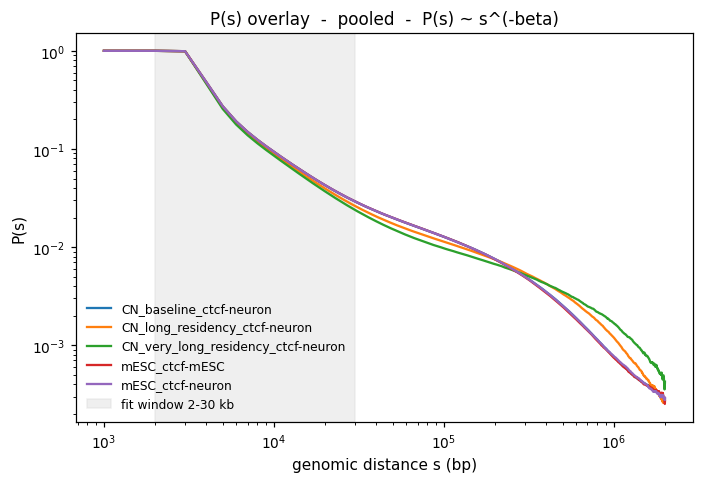


Fitted P(s) decay exponents beta (sorted ascending; smaller beta = shallower P(s) = more extruded):
  beta = 1.373   mESC_ctcf-mESC
  beta = 1.373   mESC_ctcf-neuron
  beta = 1.374   CN_baseline_ctcf-neuron
  beta = 1.412   CN_long_residency_ctcf-neuron
  beta = 1.446   CN_very_long_residency_ctcf-neuron


In [40]:
from analysis.ps_curve import compute_ps_curve, fit_ps_powerlaw

# Tunables
lower_bound_bp = 2_000
upper_bound_bp = 30_000
which = "pooled"   # "pooled" or rep index

ps_results = {}
for cond in CONDITIONS:
    bucket = by_condition[cond]
    if which == "pooled" and bucket["pooled"]:
        prefix = bucket["pooled"]
    elif bucket["reps"]:
        rep = which if isinstance(which, int) and which in bucket["reps"] else min(bucket["reps"])
        prefix = bucket["reps"][rep]
    else:
        continue
    cm = np.load(ANALYSIS_DIR / f"{prefix}_contact_map.npy")
    s_bp, ps = compute_ps_curve(cm, resolution=RESOLUTION)
    fit = fit_ps_powerlaw(s_bp, ps, lower_bound_bp, upper_bound_bp)
    ps_results[cond] = {"s_bp": s_bp, "ps": ps, "fit": fit}
    # Note: fit['exponent'] is the P(s) decay exponent beta (= 3*nu by mean field).
    print(f"{cond:35s}  beta = {fit.get('exponent', float('nan')):.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for cond, r in ps_results.items():
    s, p = r["s_bp"], r["ps"]
    mask = (s > 0) & (p > 0)
    ax.loglog(s[mask], p[mask], lw=1.5, label=cond)
ax.axvspan(lower_bound_bp, upper_bound_bp, color="0.85", alpha=0.4,
           label=f"fit window {lower_bound_bp/1e3:.0f}-{upper_bound_bp/1e3:.0f} kb")
ax.set_xlabel("genomic distance s (bp)")
ax.set_ylabel("P(s)")
ax.set_title(f"P(s) overlay  -  {which}  -  P(s) ~ s^(-beta)")
ax.legend(loc="lower left", fontsize=8, ncol=1, frameon=False)
fig.tight_layout()
plt.show()

# Print a sortable summary table (sorted by ascending beta)
print("\nFitted P(s) decay exponents beta (sorted ascending; smaller beta = shallower P(s) = more extruded):")
items = sorted(((c, r["fit"].get("exponent", float("nan"))) for c, r in ps_results.items()),
               key=lambda kv: (np.isnan(kv[1]), kv[1]))
for cond, beta in items:
    print(f"  beta = {beta:.3f}   {cond}")


## 4. AbLE — absolute loop strength on conserved CTCF anchors

The faithful port of `looptools.LoopQuantifier.quantify_loop` (see `analysis/absolute_quant.py` docstring; commit fetched 2026-04-29). For a fixed list of convergent CTCF anchor pairs, fit `image ≈ c · P(s)` per loop, subtract `c · P(s)` from the image, and sum the residual inside a circular disk of radius `quant_region_size_bins` around the anchor.

We use the **conserved-between-mESC-and-neuron** CTCF pairs (the same anchor set in both cell types), which makes the cross-condition comparison interpretable: a difference in AbLE strength reflects a difference in *cohesin dynamics on the same anchor*, not a different anchor being present in one cell type and not the other.

**Hyperparameters (defaults match upstream at 1 kb resolution):**

| param | default | meaning |
|---|---|---|
| `local_region_size_bins` | 50 | half-width of the local sub-image (kb at 1 kb/bin) |
| `quant_region_size_bins` | 10 | radius of the central disk to sum over |
| `gaussian_blur_sigma_px` | 10 | Gaussian σ for outlier detection |
| `outlier_removal_radius_px` | 10 | radius of NaN mask around each outlier loop |
| `ignore_diag_cutoff_px` | 5 | NaN out pixels with `s ≤ this` before the fit |
| `k_min` | 2 | a local max counts as outlier if it exceeds `k_min × median` |

If the AbLE values look too small or too noisy, either the matrix has too few contacts (run more replicates / longer simulations), or the disk is too large for the region's signal-to-noise ratio (try `quant_region_size_bins=5`).

**Interpretation cues:** AbLE has units of *integrated excess contacts*. It is approximately proportional to the fraction of frames in which the anchor pair is closed. Higher in long-residence / high-density (neuron) parameter sets is the predicted direction. Compare to MSD plateaus on the same pairs — if AbLE goes up but the MSD plateau doesn't drop, something is off.



In [41]:
from analysis.absolute_quant import (
    LoopQuantifier, batch_absolute_quant, able_pairs_across_conditions,
    enumerate_convergent_ctcf_loops,
)
from analysis.ps_curve import compute_ps_curve

# Tunables
local_region_size_bins   = 50
quant_region_size_bins   = 10
gaussian_blur_sigma_px   = 10.0
ignore_diag_cutoff_px    = 5
k_min                    = 2.0

# Load conserved CTCF pairs from the BED used by the cluster pipeline
ctcf_bed = DATA_DIR / "ctcf_oriented_CONSERVED_mESC_CN_chr3.bed"
ctcf_positions, ctcf_orientations = [], []
if ctcf_bed.exists():
    with open(ctcf_bed) as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 6 or parts[0] != CHROM:
                continue
            start, end, ori = int(parts[1]), int(parts[2]), parts[5]
            if start < REGION_START or end > REGION_END:
                continue
            mid_bp = (start + end) // 2
            mid_bin = (mid_bp - REGION_START) // RESOLUTION
            ctcf_positions.append(int(mid_bin))
            ctcf_orientations.append(+1 if ori == "+" else -1)
print(f"Loaded {len(ctcf_positions)} conserved CTCF sites in region.")

loops = enumerate_convergent_ctcf_loops(
    ctcf_positions, ctcf_orientations,
    min_size_bins=20, max_size_bins=1500,
)
print(f"Convergent pairs: {len(loops)}  (showing first 10)")
for L in loops[:10]:
    print(f"  {L.anchor1:5d} -> {L.anchor2:5d}   size={L.size_bins} bins")

# Build per-condition contact-map dict
maps_by_cond = {}
for cond in CONDITIONS:
    bucket = by_condition[cond]
    if not bucket["pooled"]:
        continue
    cm = np.load(ANALYSIS_DIR / f"{bucket['pooled']}_contact_map.npy")
    maps_by_cond[cond] = cm

if maps_by_cond and loops:
    pairs = [(L.anchor1, L.anchor2) for L in loops]
    able_res = able_pairs_across_conditions(
        maps_by_cond, pairs,
        local_region_size_bins=local_region_size_bins,
        quant_region_size_bins=quant_region_size_bins,
        gaussian_blur_sigma_px=gaussian_blur_sigma_px,
        ignore_diag_cutoff_px=ignore_diag_cutoff_px,
        k_min=k_min,
    )

    # Heatmap: rows = conditions, cols = pair labels
    plabels = able_res["pair_labels"]
    conds   = able_res["conditions"]
    M = np.array([[able_res["strength"][p].get(c, np.nan) for p in plabels]
                  for c in conds], dtype=float)

    fig, ax = plt.subplots(figsize=(1.0 * max(4, len(plabels)) + 2,
                                    0.45 * max(3, len(conds)) + 1.5))
    im = ax.imshow(M, cmap="viridis", aspect="auto")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="AbLE strength")
    ax.set_xticks(range(len(plabels)))
    ax.set_xticklabels(plabels, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(conds)))
    ax.set_yticklabels(conds, fontsize=8)
    ax.set_title(f"AbLE on conserved CTCF pairs  -  disk r={quant_region_size_bins}, local r={local_region_size_bins}")
    fig.tight_layout()
    plt.show()
    print("Median AbLE per condition:")
    for c, row in zip(conds, M):
        print(f"  {c:35s}  median = {np.nanmedian(row):.3f}")
else:
    print("(skipping AbLE: missing pooled maps or convergent pairs)")


Loaded 0 conserved CTCF sites in region.
Convergent pairs: 0  (showing first 10)
(skipping AbLE: missing pooled maps or convergent pairs)


## 5. Two-point MSD on probe pairs

The cluster pipeline writes per-pair MSD outputs as `<prefix>_msd_<label>.json` (summary scalars: α, K_α, plateau, fit window) and `<prefix>_msd_<label>.npz` (full MSD vs lag arrays). This cell loads the cached `.npz` for one or more conditions, refits with `analysis.msd_two_point.fit_msd_alpha`, and overlays.

**Why we don't recompute MSD from scratch in the notebook.** Streaming 100k frames × 28 tiles × 70k monomers from `blocks_*.h5` takes minutes per condition and 50–60 GB of working RAM if done wrong (see CLAUDE.md "Streaming MSD" landmine). The cluster job already does this safely; the notebook reads the cached `.npz` and refits only the (cheap) log-log polynomial.

**Tunable here:** `fit_lag_min` and `fit_lag_max_frac` — the lag window over which the power-law slope is read off. Pick the window where the curve is locally linear in log-log; avoid the very-short-lag transient and the very-long-lag plateau.

**Interpretation cues (Mazzocca, Narducci, Grosse-Holz, Matthias & Hansen 2025 reference values):**

- α ≈ 1.0 — free diffusion (textbook).
- α ≈ 0.5 — classical Rouse polymer (theoretical baseline).
- α ≈ 0.4 — fractal-globule prediction.
- **α ≈ 0.3** — current best in vivo estimate (Mazzocca 2025 MINFLUX), robust across 7 orders of magnitude in time.
- α ≈ 0.1–0.25 — loop-trapped pair, MSD plateau ≈ 2J (J = loop end-to-end variance).

> Loop extrusion is **constraining**: Mazzocca 2025 finds α *increases* under acute cohesin loss. So in our sweeps, neuron-like parameters (long residence, high density) should produce **lower α** than mESC. K_α (= MSD at τ=1 saved-frame unit) sets the absolute scale; convert to physical units (nm² / s²) with `analysis.calibration`.



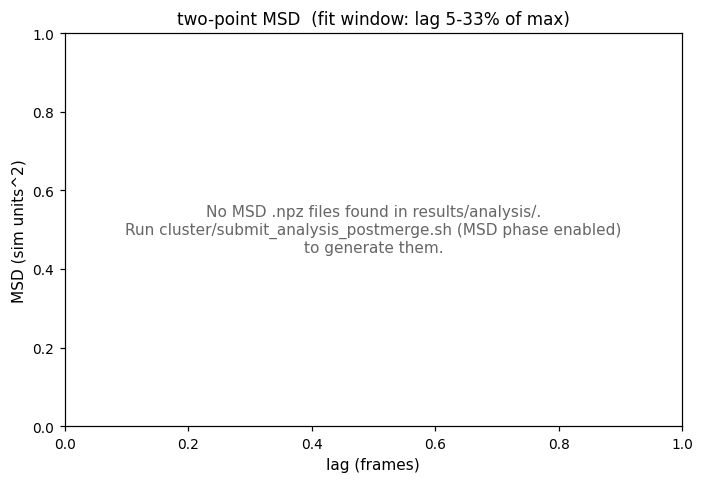


MSD summary (one pair per condition; alpha = MSD sub-diffusion exponent):
  cond                                       alpha     K_alpha  pair-file


In [42]:
from analysis.msd_two_point import fit_msd_alpha

# Tunables
fit_lag_min      = 5
fit_lag_max_frac = 1.0 / 3.0

def find_msd_npz(prefix):
    return sorted(ANALYSIS_DIR.glob(f"{prefix}_msd_*.npz"))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
msd_summary = []
for cond in CONDITIONS:
    bucket = by_condition[cond]
    if not bucket["pooled"]:
        continue
    npzs = find_msd_npz(bucket["pooled"])
    if not npzs:
        continue
    npz = np.load(npzs[0])
    lags = np.asarray(npz["lags"])
    msd  = np.asarray(npz["msd"])
    finite = np.isfinite(lags) & np.isfinite(msd) & (lags > 0) & (msd > 0)
    lags, msd = lags[finite], msd[finite]
    if lags.size < 4:
        continue
    fit = fit_msd_alpha(lags, msd, fit_lag_min=fit_lag_min,
                        fit_lag_max_frac=fit_lag_max_frac)
    alpha = fit.get("alpha")
    K_alpha = fit.get("K_alpha")
    label = f"{cond}  alpha={alpha:.2f}" if alpha is not None else cond
    ax.loglog(lags, msd, lw=1.5, label=label)
    if alpha is not None and K_alpha is not None:
        s = lags
        ax.loglog(s, K_alpha * s ** alpha, "--", color="0.4", lw=0.8, alpha=0.6)
    msd_summary.append({"cond": cond, "pair_file": npzs[0].name,
                        "alpha": alpha, "K_alpha": K_alpha,
                        "n_lags": int(lags.size)})

ax.set_xlabel("lag (frames)")
ax.set_ylabel("MSD (sim units^2)")
ax.set_title(f"two-point MSD  (fit window: lag {fit_lag_min}-{int(fit_lag_max_frac*100)}% of max)")

# Guard the legend so empty-data runs don't emit "No artists with labels found"
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, fontsize=8, loc="lower right", frameon=False)
else:
    ax.text(0.5, 0.5,
            "No MSD .npz files found in results/analysis/.\n"
            "Run cluster/submit_analysis_postmerge.sh (MSD phase enabled)\n"
            "to generate them.",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=10, color="0.4")
fig.tight_layout()
plt.show()

print("\nMSD summary (one pair per condition; alpha = MSD sub-diffusion exponent):")
print(f"  {'cond':40s}  {'alpha':>6s}  {'K_alpha':>10s}  pair-file")
for r in msd_summary:
    a = f"{r['alpha']:.3f}" if r["alpha"] is not None else "  nan"
    k = f"{r['K_alpha']:.3e}" if r["K_alpha"] is not None else "       nan"
    print(f"  {r['cond']:40s}  {a:>6s}  {k:>10s}  {r['pair_file']}")


## 6. Polymer dynamics — Rg, looped fraction, contact dwell

Companion readouts to MSD that probe the population-level state of the polymer rather than tagged-pair dynamics.

- **Radius of gyration `Rg(t)`.** Time series of the locus's overall compaction. A drop in `<Rg>` between conditions = more compact polymer = more frequent / longer-lived loops in aggregate.
- **Looped fraction.** For each anchor pair, fraction of frames in which the two monomers are within the contact-distance threshold. Direct in-silico equivalent of the BILD-inferred "fully looped" fraction in Gabriele 2022.
- **Contact dwell-time distribution.** How long a contact lasts once formed. Power-law tails reflect the LEF lifetime distribution; long tails are the neuron-parameter prediction.
- **Pair-distance distribution.** Bimodal `P(|r|)` with a peak at small `|r|` (looped) and a broader peak at large `|r|` (unlooped) is the signature of a stable loop population. Unimodal = no preferential close-state.

The cluster pipeline writes these as `<prefix>_polymer_dynamics.json`. The cell below loads them and renders side-by-side comparisons.



In [43]:
def load_dyn(prefix):
    p = ANALYSIS_DIR / f"{prefix}_polymer_dynamics.json"
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)

dyn_by_cond = {}
for cond in CONDITIONS:
    bucket = by_condition[cond]
    if not bucket["pooled"]:
        continue
    d = load_dyn(bucket["pooled"])
    if d is not None:
        dyn_by_cond[cond] = d
print(f"Loaded polymer-dynamics JSON for {len(dyn_by_cond)} conditions: "
      f"{list(dyn_by_cond.keys())}")

if dyn_by_cond:
    # Two summary panels: looped-fraction by condition, mean Rg by condition
    looped_frac = {c: d.get("looped_fraction") for c, d in dyn_by_cond.items()}
    rg_mean    = {c: d.get("rg_mean") for c, d in dyn_by_cond.items()}

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    conds = list(dyn_by_cond.keys())
    lf = [looped_frac[c] if looped_frac[c] is not None else np.nan for c in conds]
    rg = [rg_mean[c]    if rg_mean[c]    is not None else np.nan for c in conds]
    x = np.arange(len(conds))

    axes[0].bar(x, lf, color="C0")
    axes[0].set_xticks(x); axes[0].set_xticklabels(conds, rotation=30, ha="right", fontsize=7)
    axes[0].set_ylabel("looped fraction")
    axes[0].set_title("Looped fraction per condition")

    axes[1].bar(x, rg, color="C1")
    axes[1].set_xticks(x); axes[1].set_xticklabels(conds, rotation=30, ha="right", fontsize=7)
    axes[1].set_ylabel("<Rg> (sim units)")
    axes[1].set_title("Mean radius of gyration")
    fig.tight_layout()
    plt.show()


Loaded polymer-dynamics JSON for 0 conditions: []


## 7. Cross-condition summary table and interpretation

The `summary_table.csv` (and matching JSON) at `results/analysis/summary_table.csv` is the canonical cross-condition pivot — one row per metric (P(s) α at scale, AbLE median, MSD α / K_α, looped fraction, Rg, sim-vs-Hi-C SCC), one column per condition. Use it as the headline view.

**How to read the table:**

- Sort by `metric_family` to see all the P(s) rows together, then all the AbLE rows, etc.
- The `delta_vs_*` columns (if present) compare each condition against a reference (default: `mESC_ctcf-mESC`).
- `p_value` / `effect_size` columns come from the MSD-statistics phase (Welch's t / Mann-Whitney / permutation, see `analysis/msd_statistics.py`).

**Predictions to check (Sox2 mESC → neuron transition):**

| readout | mESC_ctcf-mESC (control) | CN_long_residency (neuron) | direction |
|---|---|---|---|
| P(s) α (2-30 kb) | ~1.0-1.1 | ~0.85-0.95 | shallower in neuron |
| AbLE on conserved anchors | baseline | higher | stronger CTCF dots |
| MSD α | ~0.5 (Rouse) for distant pairs | ~0.3-0.4 for stably looped | sub-diffusive |
| MSD plateau | high / no plateau | clear plateau at long lags | tighter constraint |
| looped fraction | ~6-7% | ~12-15% | more looped frames |
| <Rg> | reference | smaller | more compact |

If your sweep matches **most but not all** of these, that is the actually interesting case — the deviations tell you which mechanisms (CTCF-landscape change vs cohesin-dynamics change) explain which observables.



In [44]:
import csv

summary_csv = ANALYSIS_DIR / "summary_table.csv"
if summary_csv.exists():
    rows = []
    with open(summary_csv) as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(r)
    print(f"summary_table.csv  -  {len(rows)} rows  -  columns: {reader.fieldnames}")

    # Show the header and the first dozen rows
    if rows:
        print("\n(first 12 rows)")
        for r in rows[:12]:
            short = {k: v for k, v in r.items() if k in
                     {"metric_family", "metric", "condition", "value",
                      "alpha", "K_alpha", "looped_fraction", "rg_mean"}}
            if short:
                print("  ", short)
            else:
                print("  ", r)

    # If pandas is available, group by metric for a tidier view
    try:
        import pandas as pd
        df = pd.read_csv(summary_csv)
        if "metric" in df.columns and "condition" in df.columns and "value" in df.columns:
            pivot = df.pivot_table(index="metric", columns="condition",
                                   values="value", aggfunc="first")
            print("\nPivoted view (metric x condition):")
            with pd.option_context("display.max_columns", None,
                                   "display.width", 200,
                                   "display.float_format", lambda v: f"{v:.3f}"):
                print(pivot)
    except Exception as e:
        print(f"(pandas pivot skipped: {e})")
else:
    print(f"summary_table.csv not found at {summary_csv}")
    print("Re-run cluster/submit_analysis_postmerge.sh to regenerate.")


summary_table.csv not found at C:\Users\gabriele.michele\Documents\Claude\Projects\3D_genome_in_neurons\cohesin_sim\results\analysis\summary_table.csv
Re-run cluster/submit_analysis_postmerge.sh to regenerate.


## 8. Save figures

If you've tweaked colours / layouts above and want to keep specific panels, this is the place. Each `fig.savefig(...)` call you add here writes into `results/figures/` (configurable via `FIGURES_DIR` at the top). Keep filenames human-readable and version-tagged so they don't collide with the cluster-pipeline outputs.



In [45]:
# Example pattern (uncomment + adapt the figure variables you actually have):
# fig.savefig(FIGURES_DIR / "ps_overlay_notebook_v1.png", dpi=200, bbox_inches="tight")
# fig.savefig(FIGURES_DIR / "able_heatmap_notebook_v1.png", dpi=200, bbox_inches="tight")
print(f"FIGURES_DIR = {FIGURES_DIR}")
print("(no figures saved by default; add fig.savefig(...) calls above)")


FIGURES_DIR = C:\Users\gabriele.michele\Documents\Claude\Projects\3D_genome_in_neurons\cohesin_sim\results\figures
(no figures saved by default; add fig.savefig(...) calls above)
